# SLAP2 control blocks — example ΔF/F traces in both channels

Companion to `explore_slap2.ipynb`, which works through one stimulus block
(Zebra) on the green channel only. This notebook does two things instead:

1. Plots whole-session ΔF/F for ten example ROIs in **both** colour channels —
   green (iGluSnFR4f, glutamate) and red (RCaMP3, calcium) — with every
   stimulus block resolved, then zooms into one control block.
2. Asks whether any ROI is a **soma**, and whether a soma would stand out by
   having many more pixels than the rest.

Two things to know up front, both established below. The stimulus tables are
*not* one block each: `standard_control` holds two separate repeats of the same
standard block, one before and one after the oddball block, and they have to be
split before anything is averaged over them. And `pixel_mask` is a *weighted*
kernel over a support that neighbouring ROIs share, so `n_pixels` measures the
shared support rather than the ROI — every ROI in the session is in fact the
same size. The red channel also has no ROIs of its own.

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import ndimage

import sys
sys.path.append('..')
import utils

In [2]:
path = '../../data/slap2/sub-829704/sub-829704_ses-829704-2025-12-18-10-57-36_image+ophys.nwb'
stream = utils.open_local(path)

print(f'modality   : {stream.modality}')
print(f'session    : {stream.nwb.session_id}')
print(f'subject    : {stream.nwb.subject.subject_id}, {stream.nwb.subject.sex}, {stream.nwb.subject.age}')
print(f'DMDs       : {stream.dmds()}')

for dmd in stream.dmds():
    plane = stream.nwb.imaging_planes[f'ImagingPlane_{dmd}']
    print(f'{dmd}: {plane.location}, {plane.indicator}, '
          f'{plane.imaging_rate:.1f} Hz nominal, {len(stream.slap2_rois(dmd))} ROIs')

/tmp/nwbprobe/hdmf/spec/catalog.py:101: UserWarning: ndx-events defines a different specification for TimestampVectorData than the existing definition from nwb.event.yaml. Defaulting to the existing specification from nwb.event.yaml, but compatibility issues may be present. Please update the extension version if possible.
  self.register_spec(spec, source_file)
/tmp/nwbprobe/hdmf/spec/catalog.py:101: UserWarning: ndx-events defines a different specification for DurationVectorData than the existing definition from nwb.event.yaml. Defaulting to the existing specification from nwb.event.yaml, but compatibility issues may be present. Please update the extension version if possible.
  self.register_spec(spec, source_file)
/tmp/nwbprobe/hdmf/spec/catalog.py:101: UserWarning: ndx-events defines a different specification for MeaningsTable than the existing definition from table.yaml. Defaulting to the existing specification from table.yaml, but compatibility issues may be present. Please updat

modality   : slap2
session    : 829704_2025-12-18_10-57-36
subject    : 829704, M, P234D
DMDs       : ['DMD1', 'DMD2']
DMD1: VISp, iGluSnFR4f, RCaMP3, 107.4 Hz nominal, 50 ROIs
DMD2: VISp, iGluSnFR4f, RCaMP3, 143.0 Hz nominal, 75 ROIs


## Two channels, one ROI set

Each DMD carries four `RoiResponseSeries`: ΔF/F and F0, green and red. The
first thing to check is what they are indexed against, because that decides
whether "find the soma ROI in the red channel" is even a well-posed question.

In [3]:
DMD = 'DMD1'
fl  = stream.nwb.processing['ophys'][f'Fluorescence_{DMD}']

pd.DataFrame([{
    'series':    name,
    'n_samples': fl[name].data.shape[0],
    'n_rois':    fl[name].data.shape[1],
    'roi_table': fl[name].rois.table.name,
    'unit':      fl[name].unit,
} for name in fl.roi_response_series])

,series,n_samples,n_rois,roi_table,unit
0,DMD1_F0_green,858403,50,PlaneSegmentation_DMD1,a.u.
1,DMD1_F0_red,858403,50,PlaneSegmentation_DMD1,a.u.
2,DMD1_dFF_green,858403,50,PlaneSegmentation_DMD1,a.u.
3,DMD1_dFF_red,858403,50,PlaneSegmentation_DMD1,a.u.


In [4]:
green = fl[f'{DMD}_dFF_green']
red   = fl[f'{DMD}_dFF_red']

print('same ROI table object :', green.rois.table is red.rois.table)
print('same ROI row order    :', np.array_equal(green.rois.data[:], red.rois.data[:]))
print('ROI table columns     :', list(green.rois.table.colnames))
print('segmentations in file :',
      list(stream.nwb.processing['ophys']['ImageSegmentation'].plane_segmentations))

same ROI table object : True
same ROI row order    : True
ROI table columns     : ['z_min', 'z_max', 'pixel_mask']
segmentations in file : ['PlaneSegmentation_DMD1', 'PlaneSegmentation_DMD2']


There is exactly one `PlaneSegmentation` per DMD, and the green and red series
point at the same object with the same row order. Consequences:

* There is **no red-channel ROI set to search**. Row *i* of
  `slap2_dff(dmd, 'red')` is the same piece of tissue as row *i* of
  `slap2_dff(dmd, 'green')` — the red trace is the RCaMP3 signal read out of a
  mask that was drawn once for the DMD.
* The ROI table carries only `z_min`, `z_max` and `pixel_mask`. **Nothing in the
  file labels an ROI as soma, dendrite or spine**, so any such call has to be
  made from the masks and the reference images.

## The blocks: `standard_control` is two repeats, not one

Taking `start_time.min()` to `stop_time.max()` per interval table is wrong for
`standard_control`: it spans 42-2417 s, straight through the oddball block. The
standard block is presented **twice**, once before and once after the oddball
block, and the file already says so — `BlockLabel` splits it into
`Control block 1.1` and `Control block 1.2`, and `BlockNumber` puts them either
side of the oddball block as blocks 1 and 3.

So build the block table by grouping on `(BlockNumber, BlockLabel)` rather than
per table. That recovers nine non-overlapping blocks in presentation order, and
the 1.1/1.2 boundaries coincide with the start and end of the oddball block
without having to hard-code its times.

In [5]:
blocks = pd.DataFrame([
    {'block': int(bn), 'label': label, 'table': name, 'n_trials': len(g),
     'start': g.start_time.min(), 'stop': g.stop_time.max()}
    for name in stream.stim_tables()
    for (bn, label), g in stream.stim_df(name).groupby(['BlockNumber', 'BlockLabel'])
]).sort_values('block').reset_index(drop=True)

blocks['duration'] = blocks.stop - blocks.start
blocks['is_control'] = blocks.label.str.startswith('Control block')
blocks

,block,label,table,n_trials,start,stop,duration,is_control
0,1,Control block 1.1,standard_control,544,41.920992,422.415992,380.495000,True
1,2,Duration mismatch block,jitter_oddball,2274,422.772992,2035.998008,1613.225016,False
2,3,Control block 1.2,standard_control,544,2036.355008,2416.835000,380.479992,True
3,4,Control block 2,sequential_control_block,1120,2416.848000,2715.468016,298.620016,True
4,5,Control block 3,jitter_control,368,2715.828000,3100.299000,384.471000,True
5,6,Control block 4,open_loop_prerecorded,11520,3100.310016,3494.501333,394.191317,True
6,7,Trippy,movie,2,3494.508000,3794.500000,299.992000,False
7,8,Zebra,movie,1,3794.496000,4094.496000,300.000000,False
8,9,RF mapping,rf_mapping,1215,4094.499008,4418.454992,323.955984,False


In [6]:
# the two standard repeats bracket the oddball block exactly
oddball = blocks[blocks.table == 'jitter_oddball'].iloc[0]
first, second = blocks[blocks.table == 'standard_control'].itertuples()

print(f'oddball block        : {oddball.start:7.1f} - {oddball.stop:7.1f} s  ({oddball.label})')
print(f'{first.label}    : {first.start:7.1f} - {first.stop:7.1f} s  '
      f'(ends {oddball.start - first.stop:.1f} s before the oddball block)')
print(f'{second.label}    : {second.start:7.1f} - {second.stop:7.1f} s  '
      f'(starts {second.start - oddball.stop:.1f} s after it)')
print(f'\nsame stimulus both times: {first.n_trials} and {second.n_trials} trials, '
      f'{first.duration:.0f} s and {second.duration:.0f} s')

oddball block        :   422.8 -  2036.0 s  (Duration mismatch block)
Control block 1.1    :    41.9 -   422.4 s  (ends 0.4 s before the oddball block)
Control block 1.2    :  2036.4 -  2416.8 s  (starts 0.4 s after it)

same stimulus both times: 544 and 544 trials, 380 s and 380 s


`Control block 1.1` and `1.2` are the same stimulus, so they get the same
colour below, but they are shaded as two separate spans.

In [7]:
CONTROL_COLOURS = {
    'Control block 1.1': 'tab:blue',    # same stimulus, presented twice, so
    'Control block 1.2': 'tab:blue',    # one colour and two separate spans
    'Control block 2':   'tab:purple',
    'Control block 3':   'tab:cyan',
    'Control block 4':   'tab:olive',
}

def shade_blocks(ax, blocks, colours=CONTROL_COLOURS, alpha=.13):
    """Shade the control blocks of `blocks` onto `ax`, x in minutes."""
    for b in blocks.itertuples():
        if b.label in colours:
            ax.axvspan(b.start / 60, b.stop / 60, color=colours[b.label],
                       alpha=alpha, zorder=0)


def draw_timeline(ax, blocks, colours=CONTROL_COLOURS):
    """One lane with every block in order, numbered, controls coloured."""
    for b in blocks.itertuples():
        ax.barh(0, b.duration / 60, left=b.start / 60, height=.6,
                color=colours.get(b.label, '.75'),
                edgecolor='w', lw=.6)
        ax.text((b.start + b.stop) / 120, 0, str(b.block), ha='center', va='center',
                fontsize=8, color='k')
    ax.set_yticks([])
    ax.set_ylim(-.45, .45)
    for side in ('left', 'right', 'top'):
        ax.spines[side].set_visible(False)

## Whole-session ΔF/F for ten example ROIs

The full ΔF/F array is 858403 x 50 float64 per series, ~340 MB, and we want two
of them across 73 minutes. So the overview traces are reduced while being read:
each output point is the mean of `step` consecutive samples.

In [8]:
def load_dff_decimated(stream, dmd, channel, roi_idx, step=200, block=200_000):
    '''Whole-session ΔF/F for selected ROIs, block-averaged by `step` samples.

    Reading every sample of both channels would be ~700 MB, so the trace is
    reduced on the fly. Returns (times, traces) with traces (n_rois, n_out).
    '''
    rrs     = stream.nwb.processing['ophys'][f'Fluorescence_{dmd}'][f'{dmd}_dFF_{channel}']
    roi_idx = np.asarray(roi_idx)
    n       = rrs.data.shape[0]

    t_out, d_out = [], []
    with warnings.catch_warnings():
        # a reduction window can be entirely NaN (blanked samples); that is the answer
        warnings.simplefilter('ignore', RuntimeWarning)
        for a in range(0, n, block):
            m = ((min(a + block, n) - a) // step) * step
            if m == 0:
                continue
            chunk = rrs.data[a:a + m, :][:, roi_idx]
            t_out.append(rrs.timestamps[a:a + m].reshape(-1, step).mean(axis=1))
            d_out.append(np.nanmean(chunk.reshape(-1, step, len(roi_idx)), axis=1))

    return np.concatenate(t_out), np.concatenate(d_out).T

For the ten examples, spread the picks over the field of view rather than
taking `range(10)` — consecutive ROI indices sit a few pixels apart on the same
structure (shown further down), so the first ten rows would all be neighbours.
`slap2_rois()` reports weighted centroids, which are distinct for every row.

In [9]:
rois = stream.slap2_rois(DMD)
print(f'{len(rois)} rows, {len(rois[["x", "y"]].drop_duplicates())} distinct centroids')

# order along the field of view, then take an even spread
along   = np.argsort(rois.y.to_numpy())
roi_idx = np.sort(along[np.linspace(0, len(along) - 1, 10).astype(int)])
print('plotting ROIs:', roi_idx)
rois.loc[roi_idx, ['roi_id', 'n_pixels', 'x', 'y']]

50 rows, 50 distinct centroids
plotting ROIs: [ 0  5 10 16 21 26 31 37 42 48]


,roi_id,n_pixels,x,y
0,0,109,330.699806,58.822065
5,5,109,222.376470,119.968608
10,10,109,227.327894,142.988053
16,16,182,260.902768,187.949946
21,21,93,132.539257,282.743763
26,26,77,285.246061,399.525025
31,31,97,267.756790,416.784485
37,37,109,253.227739,467.178524
42,42,101,255.493363,484.725487
48,48,108,206.149075,574.260154


In [10]:
times, dff_green = load_dff_decimated(stream, DMD, 'green', roi_idx)
_,     dff_red   = load_dff_decimated(stream, DMD, 'red',   roi_idx)

segments = stream.slap2_segments(DMD)
raw_ts   = stream.nwb.processing['ophys'][f'Fluorescence_{DMD}'][f'{DMD}_dFF_green'].timestamps[:]

print(f'{dff_green.shape[1]} points at {np.median(np.diff(times)):.2f} s spacing, '
      f'{times[0]:.0f}-{times[-1]:.0f} s')
print(f'imaging: {segments.duration.sum():.0f} s in {len(segments)} bouts '
      f'({100 * segments.duration.sum() / (raw_ts[-1] - raw_ts[0]):.0f} % of the session), '
      f'longest blanking gap {np.diff(raw_ts).max():.2f} s')

4292 points at 1.00 s spacing, 41-4418 s
imaging: 4292 s in 147 bouts (98 % of the session), longest blanking gap 0.60 s


Each trace is scaled to its own 1st-99th percentile and offset by one unit, so
the ROIs can be compared within a channel; absolute amplitudes are printed
separately below. The top lane numbers the nine blocks in order — blocks 1 and
3 are the two standard-control repeats, block 2 the oddball between them.

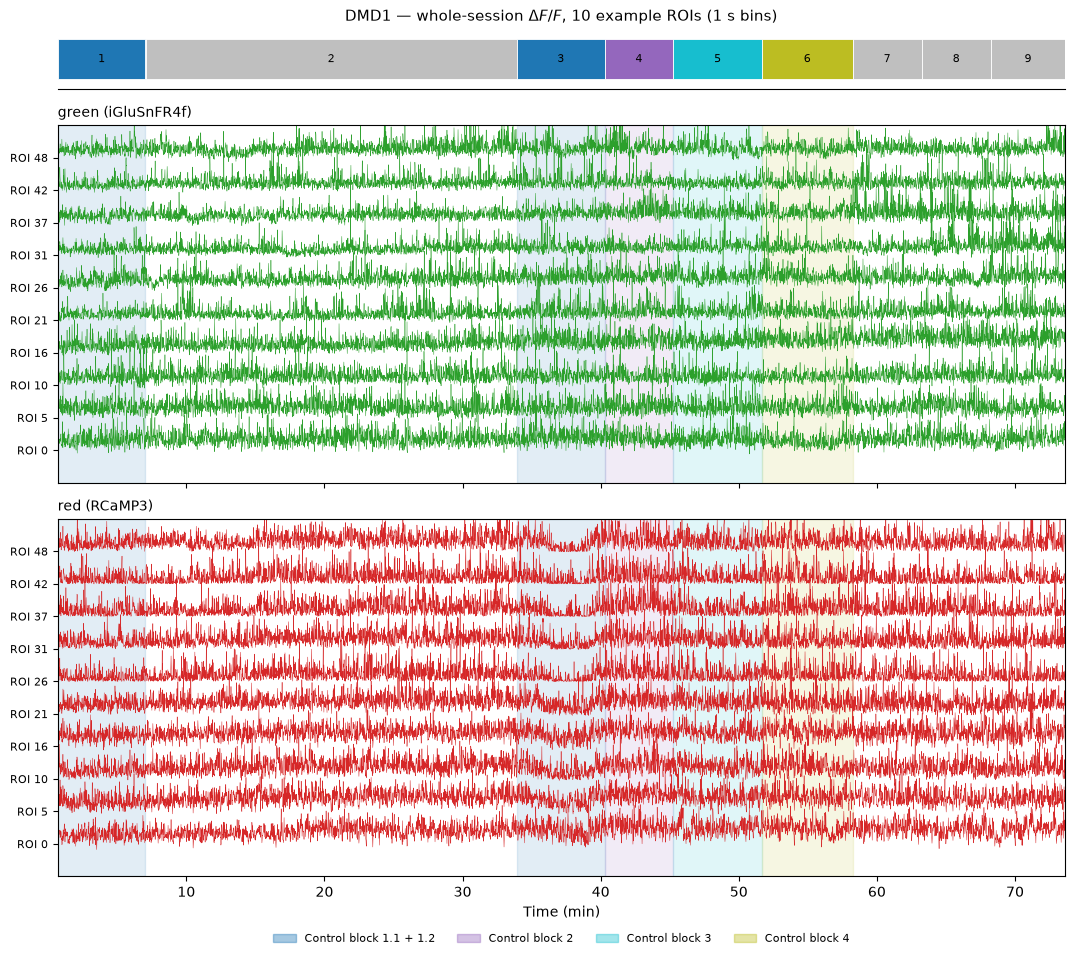

In [11]:
f = plt.figure(figsize=(13, 11))
gs = f.add_gridspec(3, 1, height_ratios=[.5, 3, 3], hspace=.14)

ax_tl = f.add_subplot(gs[0])
draw_timeline(ax_tl, blocks)
ax_tl.tick_params(labelbottom=False, bottom=False)
ax_tl.set_title(f'{DMD} — whole-session $\\Delta F/F$, 10 example ROIs '
                f'({np.median(np.diff(times)):.0f} s bins)', fontsize=11)

axes = [f.add_subplot(gs[i + 1], sharex=ax_tl) for i in range(2)]
panels = [('green (iGluSnFR4f)', dff_green, 'tab:green'),
          ('red (RCaMP3)',       dff_red,   'tab:red')]

for ax, (label, arr, colour) in zip(axes, panels):
    for k, roi in enumerate(roi_idx):
        trace  = arr[k]
        lo, hi = np.nanpercentile(trace, [1, 99])
        ax.plot(times / 60, k + (trace - lo) / (hi - lo), lw=.35, color=colour)

    shade_blocks(ax, blocks)
    ax.set_yticks(np.arange(len(roi_idx)))
    ax.set_yticklabels([f'ROI {r}' for r in roi_idx], fontsize=8)
    ax.set_ylim(-1, len(roi_idx))
    ax.set_title(label, fontsize=10, loc='left')

axes[0].tick_params(labelbottom=False)

# one legend entry per colour; 1.1 and 1.2 share theirs
seen = {}
for b in blocks[blocks.is_control].itertuples():
    seen.setdefault(CONTROL_COLOURS[b.label], b.label.replace('.1', '.1 + 1.2'))
for colour, label in seen.items():
    axes[1].axvspan(np.nan, np.nan, color=colour, alpha=.4, label=label)
axes[1].legend(loc='upper center', bbox_to_anchor=(.5, -.13), ncol=4, fontsize=8,
               frameon=False)

axes[1].set_xlabel('Time (min)')
ax_tl.set_xlim(times[0] / 60, times[-1] / 60)
plt.show()

Worth noting before reading amplitudes off these traces: the stored "dFF" is
non-negative with a positive baseline, so it behaves like $F/F_0$ rather than a
zero-centred $\Delta F/F$.

In [12]:
for ch, arr in [('green', dff_green), ('red', dff_red)]:
    print(f'{ch:5s}: min {np.nanmin(arr):6.3f}  p1 {np.nanpercentile(arr, 1):6.3f}  '
          f'median {np.nanmedian(arr):6.3f}  p99 {np.nanpercentile(arr, 99):6.3f}  '
          f'max {np.nanmax(arr):6.3f}')

green: min  0.107  p1  0.185  median  0.540  p99  1.305  max  3.137
red  : min  0.000  p1  0.013  median  0.464  p99  1.443  max  4.008


### The two standard-control repeats side by side

With the block split in hand, the obvious check is whether the same stimulus
gives the same thing the second time round. Mean ΔF/F per ROI in each repeat:

In [13]:
def block_mean(times, traces, block):
    """Mean of each trace inside one block's time span."""
    sel = (times >= block.start) & (times <= block.stop)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        return np.nanmean(traces[:, sel], axis=1)

rep1, rep2 = blocks[blocks.table == 'standard_control'].itertuples()

repeat = pd.DataFrame({
    'roi':         roi_idx,
    'green_1.1':   block_mean(times, dff_green, rep1),
    'green_1.2':   block_mean(times, dff_green, rep2),
    'red_1.1':     block_mean(times, dff_red,   rep1),
    'red_1.2':     block_mean(times, dff_red,   rep2),
}).set_index('roi')
repeat.round(3)

,green_1.1,green_1.2,red_1.1,red_1.2
roi,,,,
0,0.663,0.733,0.373,0.454
5,0.432,0.428,0.484,0.538
10,0.474,0.485,0.450,0.453
16,0.228,0.277,0.546,0.572
21,0.411,0.507,0.508,0.548
26,0.612,0.740,0.276,0.287
31,0.469,0.523,0.371,0.364
37,0.638,0.731,0.284,0.289
42,0.636,0.772,0.275,0.289


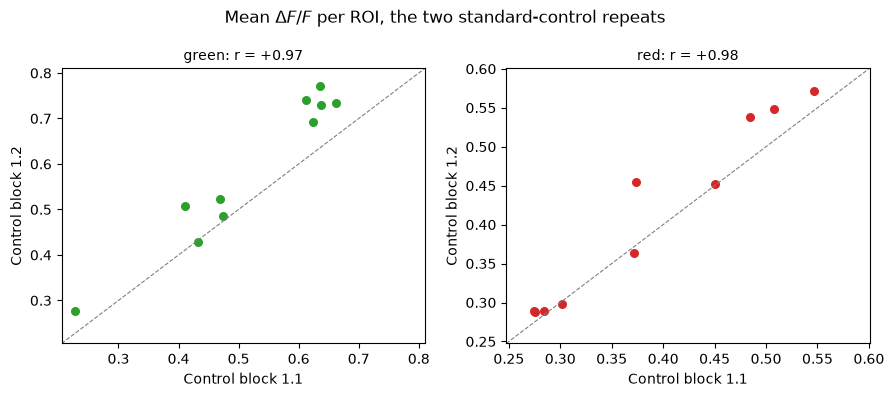

In [14]:
f, axs = plt.subplots(1, 2, figsize=(9, 4))
for ax, (ch, colour) in zip(axs, [('green', 'tab:green'), ('red', 'tab:red')]):
    a, b = repeat[f'{ch}_1.1'], repeat[f'{ch}_1.2']
    ax.scatter(a, b, s=30, color=colour)
    lim = [min(a.min(), b.min()) * .9, max(a.max(), b.max()) * 1.05]
    ax.plot(lim, lim, '--', color='.5', lw=.8)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Control block 1.1'); ax.set_ylabel('Control block 1.2')
    ax.set_title(f'{ch}: r = {a.corr(b):+.2f}', fontsize=10)
f.suptitle('Mean $\\Delta F/F$ per ROI, the two standard-control repeats')
f.tight_layout()

The two repeats agree closely across ROIs (r ~ 0.97 in both channels), but most
points sit slightly above the diagonal: the second repeat runs a little higher,
so there is a small session-long drift on top of a stable ROI ranking. Worth
keeping in mind if the two repeats get pooled rather than compared.

### Zoom: one control block at native resolution

`load_dff_decimated` is only for the overview. For a single block, read the
window itself — `slap2_dff()` slices by time so only that stretch comes off
disk. Green resolves individual events at the full ~215 Hz; red is visibly
slower, as expected from RCaMP3's calcium kinetics.

In [15]:
block = stream.stim_df('jitter_control')
t0, t1 = block.start_time.min(), block.start_time.min() + 60.

zoom_green = stream.slap2_dff(DMD, channel='green', t_start=t0, t_stop=t1)
zoom_red   = stream.slap2_dff(DMD, channel='red',   t_start=t0, t_stop=t1)
zt = zoom_green.columns.to_numpy()

print(f'jitter_control: {len(block)} trials, '
      f'{block.start_time.min():.0f}-{block.stop_time.max():.0f} s, '
      f'trial types {sorted(block.TrialType.unique())}')
print(f'zoom window {t0:.0f}-{t1:.0f} s -> {zoom_green.shape[1]} samples '
      f'({1 / np.median(np.diff(zt)):.0f} Hz effective)')

jitter_control: 368 trials, 2716-3100 s, trial types ['omission', 'single']
zoom window 2716-2776 s -> 11765 samples (215 Hz effective)


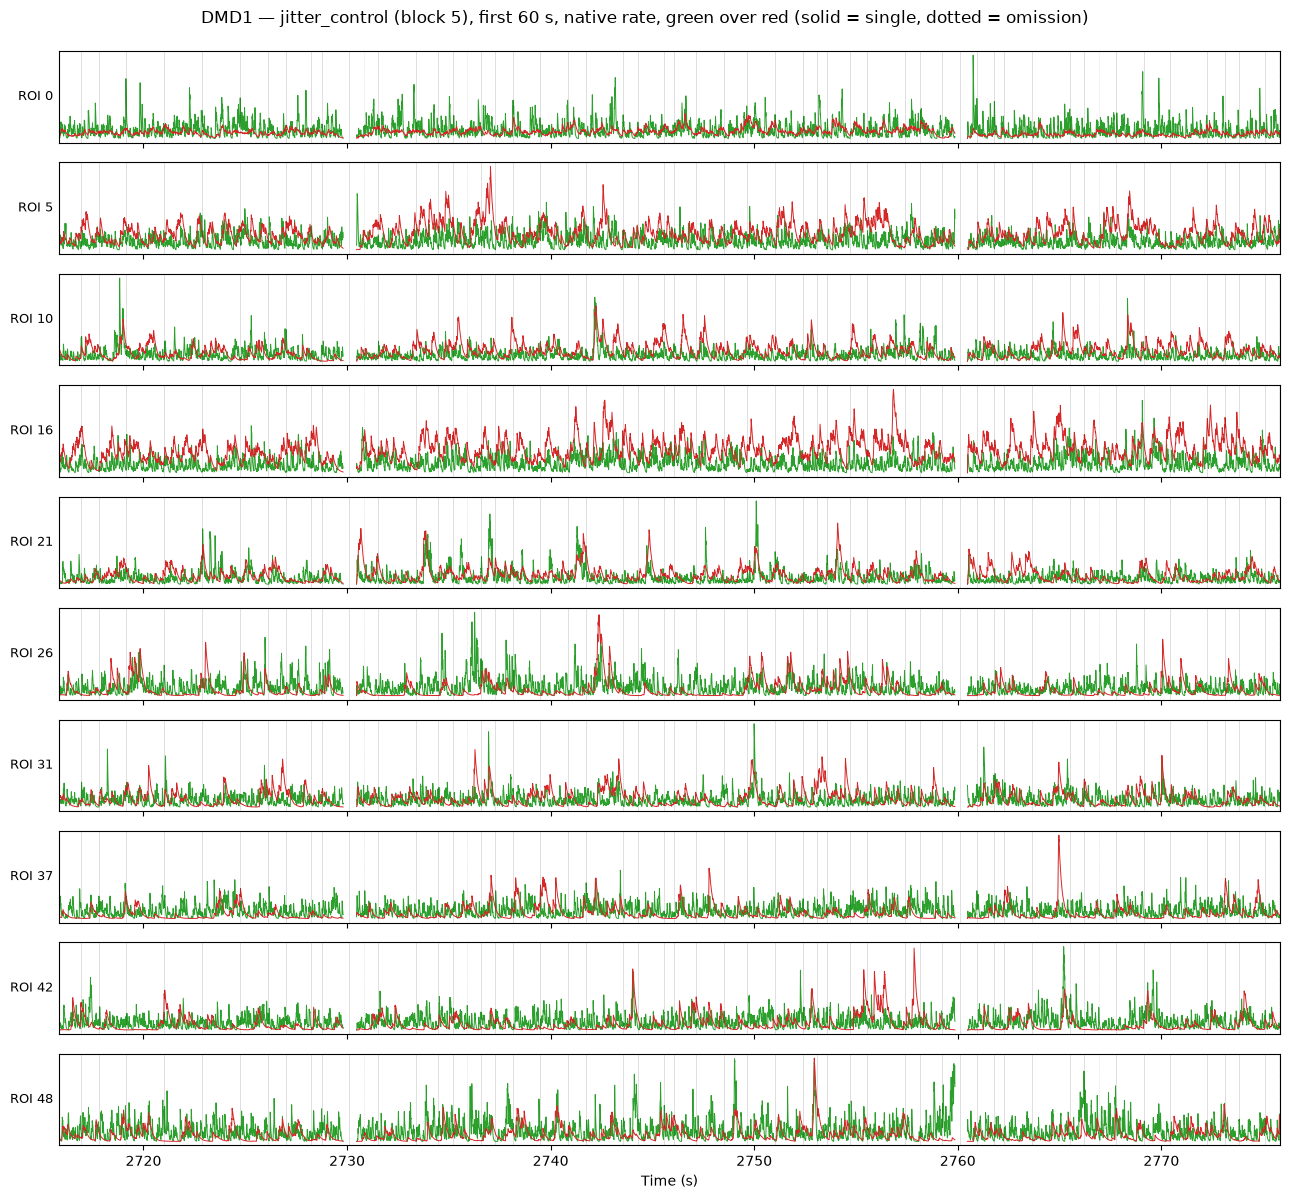

In [16]:
f, axs = plt.subplots(len(roi_idx), 1, figsize=(13, 12), sharex=True)

for ax, roi in zip(axs, roi_idx):
    ax.plot(zt, zoom_green.loc[roi].values, lw=.7, color='tab:green')
    ax.plot(zt, zoom_red.loc[roi].values,   lw=.7, color='tab:red')
    ax.set_ylabel(f'ROI {roi}', rotation=0, ha='right', va='center', fontsize=9)
    ax.set_yticks([])

# trial onsets, split by whether the grating was shown or omitted
for trial_type, style in [('single', '-'), ('omission', ':')]:
    onsets = block.loc[block.TrialType == trial_type, 'start_time']
    for onset in onsets[(onsets >= t0) & (onsets <= t1)]:
        for ax in axs:
            ax.axvline(onset, color='k', alpha=.18, lw=.5, ls=style)

axs[-1].set_xlabel('Time (s)')
axs[-1].set_xlim(t0, t1)
f.suptitle(f'{DMD} — jitter_control (block 5), first 60 s, native rate, green over red '
           '(solid = single, dotted = omission)', y=.995)
f.tight_layout()

## Is there a soma ROI — and would it have more pixels?

Nothing in the NWB labels ROI type, so this has to come from the masks and the
two reference images. The critical detail is that `pixel_mask` stores a
*weight* per pixel, normalised to sum to 1, and the weights are concentrated in
a small blob inside a much larger support. Two very different notions of size
follow:

* `support_px` — how many pixels the mask lists. This is what `n_pixels` in
  `slap2_rois()` counts, and it is the quantity the "soma has more pixels" idea
  appeals to.
* `effective_px` — $1/\sum_i w_i^2$, the participation ratio of the weights:
  how many pixels actually contribute to the trace.

In [17]:
def roi_geometry(stream, dmd):
    '''Per-ROI support size, effective size, shape and mean-image brightness.

    roundness is sqrt(l2/l1) of the weight-weighted coordinate covariance:
    1 for an isotropic blob, towards 0 for a line.
    '''
    rois  = stream.slap2_rois(dmd)
    green = stream.slap2_mean_image(dmd, channel=0)
    red   = stream.slap2_mean_image(dmd, channel=1)

    out = []
    for row in rois.itertuples():
        m = row.pixel_mask
        x, y, w = m['x'].astype(float), m['y'].astype(float), m['weight'].astype(float)

        cx, cy = (x * w).sum(), (y * w).sum()
        cov = np.array([[np.sum(w * (x - cx) ** 2),      np.sum(w * (x - cx) * (y - cy))],
                        [np.sum(w * (x - cx) * (y - cy)), np.sum(w * (y - cy) ** 2)]])
        ev = np.sort(np.linalg.eigvalsh(cov))[::-1]

        yi, xi = m['y'].astype(int), m['x'].astype(int)
        g = float(np.nansum(green[yi, xi] * w))
        r = float(np.nansum(red[yi, xi] * w))

        out.append({
            'dmd':            dmd,
            'roi':            row.Index,
            'support_px':     row.n_pixels,
            'effective_px':   1. / np.sum(w ** 2),
            'roundness':      float(np.sqrt(ev[1] / ev[0])) if ev[0] > 0 else 0.,
            'x':              cx,
            'y':              cy,
            'green':          g,
            'red':            r,
            'red_over_green': r / g if g > 0 else np.nan,
        })
    return pd.DataFrame(out)

geom = pd.concat([roi_geometry(stream, d) for d in stream.dmds()], ignore_index=True)
geom.groupby('dmd')[['support_px', 'effective_px', 'roundness', 'red_over_green']].describe().T

dmd                         DMD1        DMD2
support_px     count   50.000000   75.000000
               mean   119.600000  155.466667
               std     34.655741  101.458464
               min     76.000000   80.000000
               25%     99.500000  109.000000
               50%    109.000000  109.000000
               75%    148.000000  160.000000
               max    194.000000  458.000000
effective_px   count   50.000000   75.000000
               mean    29.071821   29.254949
               std      1.792790    1.703105
               min     23.136812   23.924090
               25%     28.367929   28.352184
               50%     29.524942   29.819835
               75%     30.260980   30.492050
               max     31.134120   31.432635
roundness      count   50.000000   75.000000
               mean     0.928625    0.933490
               std      0.038367    0.038945
               min      0.818736    0.829650
               25%      0.910399    0.909542
               50%      0.931202    0.939451
               75%      0.955297    0.963106
               max      0.988425    0.992650
red_over_green count   50.000000   75.000000
               mean     0.241819    0.244341
               std      0.113040    0.074223
               min      0.120789    0.139940
               25%      0.176579    0.181072
               50%      0.227496    0.236617
               75%      0.258229    0.296644
               max      0.868669    0.448155

### The size hypothesis fails

`support_px` ranges from 76 to 458, but `effective_px` is ~30 for every single
ROI in both DMDs, and the two are uncorrelated. Weighted roundness is 0.82-0.99
throughout. In other words the segmentation is a set of near-identical round
Gaussian-like sampling kernels of ~30 effective pixels — **no ROI is bigger
than any other**, so no amount of sorting by pixel count will surface a soma.

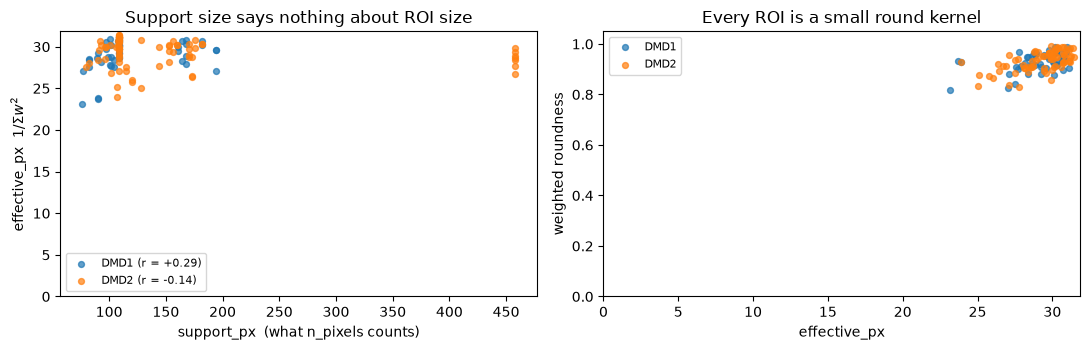

In [18]:
f, axs = plt.subplots(1, 2, figsize=(11, 3.6))

for dmd, colour in zip(stream.dmds(), ['tab:blue', 'tab:orange']):
    sub = geom[geom.dmd == dmd]
    axs[0].scatter(sub.support_px, sub.effective_px, s=18, alpha=.7,
                   color=colour, label=f'{dmd} (r = {sub.support_px.corr(sub.effective_px):+.2f})')
    axs[1].scatter(sub.effective_px, sub.roundness, s=18, alpha=.7, color=colour, label=dmd)

axs[0].set_xlabel('support_px  (what n_pixels counts)')
axs[0].set_ylabel('effective_px  $1/\\Sigma w^2$')
axs[0].set_ylim(0, None)
axs[0].set_title('Support size says nothing about ROI size')

axs[1].set_xlabel('effective_px')
axs[1].set_ylabel('weighted roundness')
axs[1].set_xlim(0, None); axs[1].set_ylim(0, 1.05)
axs[1].set_title('Every ROI is a small round kernel')

for ax in axs:
    ax.legend(fontsize=8)
f.tight_layout()

The reason a support can reach 458 pixels is that **neighbouring ROIs share
one**. The seven DMD2 rows below all list the same 458-pixel support, but their
weighted centroids step along it about 4-5 pixels at a time — seven sampling
points tiling one elongated structure, not seven copies of one ROI.

In [19]:
share = geom[(geom.dmd == 'DMD2') & (geom.support_px == 458)]
share[['roi', 'support_px', 'effective_px', 'roundness', 'x', 'y']]

,roi,support_px,effective_px,roundness,x,y
88,38,458,26.728235,0.914530,89.549688,689.898480
89,39,458,29.414174,0.952318,89.988261,695.229323
90,40,458,28.836711,0.972234,90.755930,699.869169
91,41,458,27.703774,0.939451,94.653741,703.204684
92,42,458,29.881044,0.992650,92.976576,708.049943
93,43,458,28.626165,0.933098,90.149647,712.725595
94,44,458,28.350772,0.889727,87.055561,716.059266


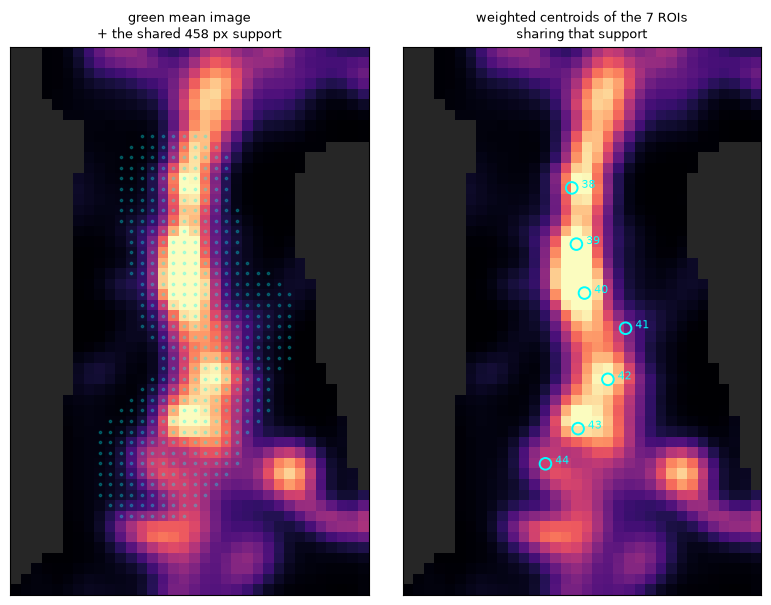

In [20]:
mask_shared = stream.slap2_rois('DMD2').pixel_mask[share.roi.iloc[0]]
img         = stream.slap2_mean_image('DMD2', channel=0)

pad = 8
ys, xs = mask_shared['y'].astype(int), mask_shared['x'].astype(int)
y0, y1 = ys.min() - pad, ys.max() + pad
x0, x1 = xs.min() - pad, xs.max() + pad

f, axs = plt.subplots(1, 2, figsize=(8, 6))

crop = img[y0:y1, x0:x1]
lo, hi = np.nanpercentile(crop, [2, 98])
axs[0].imshow(crop, cmap='magma', vmin=lo, vmax=hi, interpolation='nearest')
axs[0].scatter(xs - x0, ys - y0, s=3, color='cyan', alpha=.25)
axs[0].set_title('green mean image\n+ the shared 458 px support', fontsize=9)

axs[1].imshow(crop, cmap='magma', vmin=lo, vmax=hi, interpolation='nearest')
axs[1].scatter(share.x - x0, share.y - y0, s=70, facecolors='none',
               edgecolors='cyan', lw=1.4)
for row in share.itertuples():
    axs[1].annotate(str(row.roi), (row.x - x0, row.y - y0), color='cyan',
                    fontsize=8, xytext=(7, 0), textcoords='offset points')
axs[1].set_title('weighted centroids of the 7 ROIs\nsharing that support', fontsize=9)

for ax in axs:
    ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor('.15')
f.tight_layout()

### What does separate the ROIs: red brightness

Since size is uninformative, the usable marker is how a location looks in the
red reference image, because RCaMP3 fills the cytosol while the glutamate
sensor decorates membranes. Ranking by `red_over_green` gives exactly one
outlier.

In [21]:
top = geom.sort_values('red_over_green', ascending=False)
print('median red/green per DMD:',
      geom.groupby('dmd').red_over_green.median().round(3).to_dict())
top.head(8)[['dmd', 'roi', 'support_px', 'effective_px', 'roundness',
             'green', 'red', 'red_over_green']]

median red/green per DMD: {'DMD1': 0.227, 'DMD2': 0.237}


,dmd,roi,support_px,effective_px,roundness,green,red,red_over_green
0,DMD1,0,109,30.264291,0.917611,11.230447,9.755542,0.868669
81,DMD2,31,109,29.436375,0.905821,7.163266,3.210256,0.448155
46,DMD1,46,99,28.794844,0.965822,6.412526,2.761222,0.430598
48,DMD1,48,108,30.690212,0.941581,10.056244,3.922833,0.390089
58,DMD2,8,128,25.058258,0.833216,6.004175,2.298782,0.382864
50,DMD2,0,170,29.041110,0.943630,7.039271,2.664413,0.378507
99,DMD2,49,108,30.084968,0.906934,7.618359,2.864244,0.375966
35,DMD1,35,90,29.261964,0.907205,6.996432,2.597697,0.371289


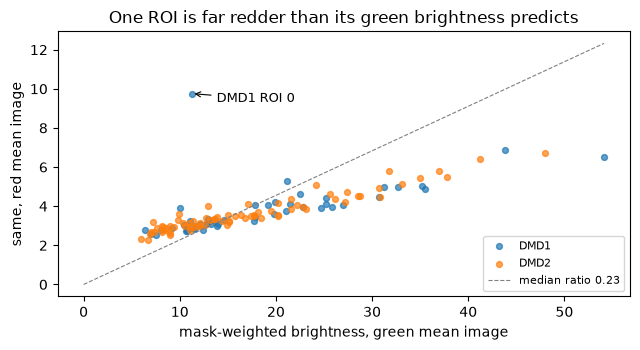

In [22]:
f, ax = plt.subplots(figsize=(6.5, 3.6))
for dmd, colour in zip(stream.dmds(), ['tab:blue', 'tab:orange']):
    sub = geom[geom.dmd == dmd]
    ax.scatter(sub.green, sub.red, s=18, alpha=.7, color=colour, label=dmd)

best = top.iloc[0]
ax.annotate(f'{best.dmd} ROI {int(best.roi)}', (best.green, best.red),
            xytext=(18, -6), textcoords='offset points', fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=.8))

lim = np.linspace(0, geom.green.max(), 10)
ratio = geom.red_over_green.median()
ax.plot(lim, ratio * lim, '--', color='.5', lw=.8, label=f'median ratio {ratio:.2f}')

ax.set_xlabel('mask-weighted brightness, green mean image')
ax.set_ylabel('same, red mean image')
ax.set_title('One ROI is far redder than its green brightness predicts')
ax.legend(fontsize=8)
f.tight_layout()

### ROI 0 against every other ROI on DMD1

The close-up alone cannot say whether this is a cell body, so put it in context:
the whole DMD1 field of view, every ROI, and the scanned patches they sit in.
SLAP2 scans only selected lines, so the field of view breaks into a handful of
disconnected patches; `ndimage.label` recovers them and tells us which ROIs
share a patch with the candidate.

In [23]:
CAND_DMD = best.dmd
CAND_ROI = int(best.roi)

cand_rois  = stream.slap2_rois(CAND_DMD)
green_full = stream.slap2_mean_image(CAND_DMD, channel=0)
red_full   = stream.slap2_mean_image(CAND_DMD, channel=1)

scanned, n_patch = ndimage.label(np.isfinite(green_full))
cand_rois = cand_rois.assign(
    patch=scanned[cand_rois.y.round().astype(int), cand_rois.x.round().astype(int)],
    red_over_green=geom.loc[geom.dmd == CAND_DMD, 'red_over_green'].to_numpy())

patch_summary = cand_rois.groupby('patch').agg(
    n_rois=('roi_id', 'size'),
    median_red_over_green=('red_over_green', 'median'),
    y_min=('y', 'min'), y_max=('y', 'max'))
patch_summary['patch_px'] = [int((scanned == p).sum()) for p in patch_summary.index]

print(f'{n_patch} disconnected scanned patches, '
      f'{100 * np.isfinite(green_full).mean():.0f} % of the FOV scanned')
print(f'ROI {CAND_ROI} is in patch {int(cand_rois.patch[CAND_ROI])}, together with '
      f'{cand_rois.index[cand_rois.patch == cand_rois.patch[CAND_ROI]].tolist()}')
patch_summary.round(3)

8 disconnected scanned patches, 6 % of the FOV scanned
ROI 0 is in patch 1, together with [0, 1]


,n_rois,median_red_over_green,y_min,y_max,patch_px
patch,,,,,
1,2,0.561,58.822,66.221,1623
3,17,0.211,107.248,199.676,4834
4,1,0.339,253.608,253.608,742
5,2,0.219,273.500,282.744,619
6,4,0.152,285.486,295.728,639
7,23,0.253,397.086,574.260,5855
8,1,0.173,400.628,400.628,653


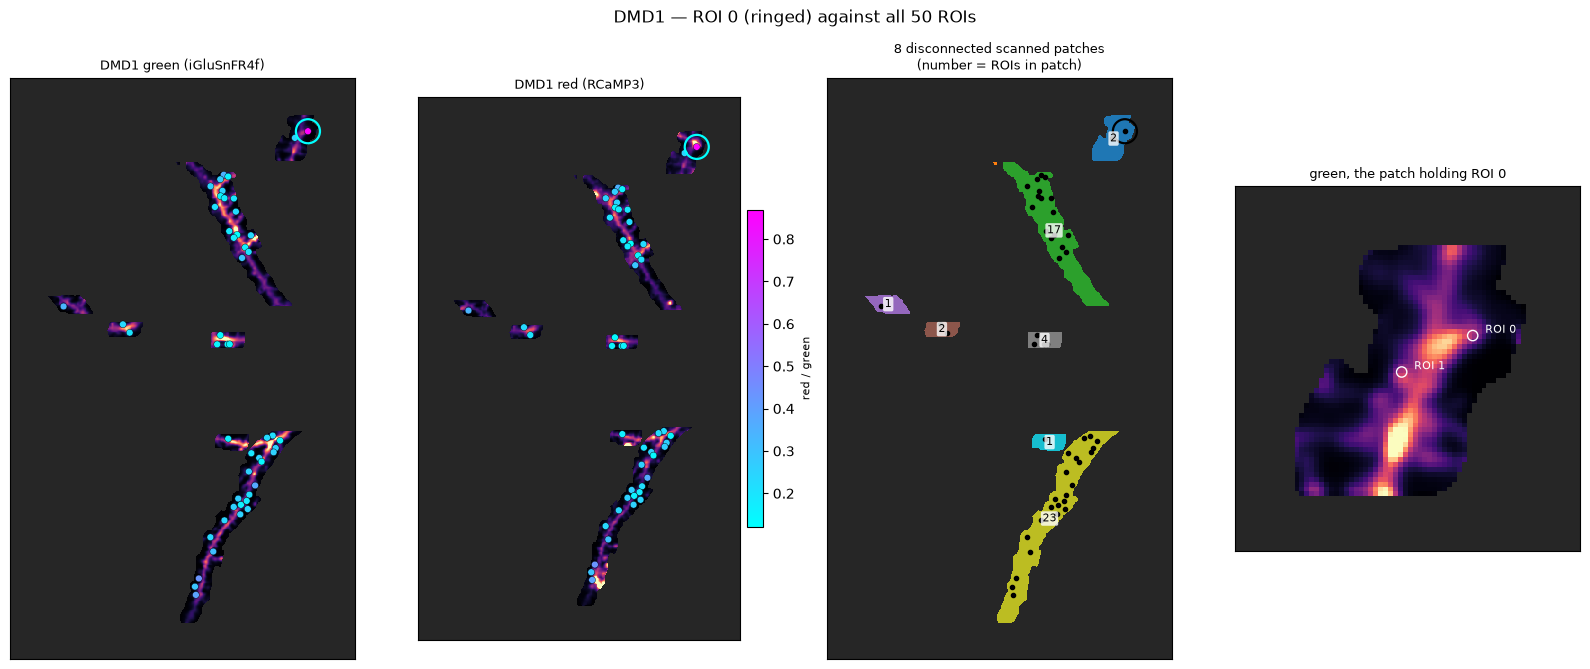

In [24]:
f, axs = plt.subplots(1, 4, figsize=(16, 7))

for ax, (label, img) in zip(axs[:2], [('green (iGluSnFR4f)', green_full),
                                      ('red (RCaMP3)', red_full)]):
    lo, hi = np.nanpercentile(img, [2, 99])
    ax.imshow(img, cmap='magma', vmin=lo, vmax=hi, interpolation='nearest')
    sc = ax.scatter(cand_rois.x, cand_rois.y, c=cand_rois.red_over_green, s=24,
                    cmap='cool', edgecolors='k', linewidths=.3)
    ax.scatter(cand_rois.x[CAND_ROI], cand_rois.y[CAND_ROI], s=300,
               facecolors='none', edgecolors='cyan', lw=1.6)
    ax.set_title(f'{CAND_DMD} {label}', fontsize=9)

cb = f.colorbar(sc, ax=axs[1], fraction=.046, pad=.02)
cb.set_label('red / green', fontsize=8)

axs[2].imshow(np.ma.masked_where(scanned == 0, scanned % 9), cmap='tab10',
              interpolation='nearest')
axs[2].scatter(cand_rois.x, cand_rois.y, s=9, color='k')
axs[2].scatter(cand_rois.x[CAND_ROI], cand_rois.y[CAND_ROI], s=300,
               facecolors='none', edgecolors='k', lw=1.6)
for p, row in patch_summary.iterrows():
    ys, xs = np.where(scanned == p)
    axs[2].text(xs.mean(), ys.mean(), f'{int(row.n_rois)}', ha='center', va='center',
                fontsize=8, color='k',
                bbox=dict(boxstyle='round,pad=.15', fc='w', ec='none', alpha=.8))
axs[2].set_title(f'{n_patch} disconnected scanned patches\n(number = ROIs in patch)',
                 fontsize=9)

# panel 4: the candidate's own patch, cropped to its bounding box
ys, xs = np.where(scanned == cand_rois.patch[CAND_ROI])
pad = 12
y0, y1 = max(ys.min() - pad, 0), ys.max() + pad
x0, x1 = max(xs.min() - pad, 0), xs.max() + pad
crop = green_full[y0:y1, x0:x1]
lo, hi = np.nanpercentile(crop, [2, 99])
axs[3].imshow(crop, cmap='magma', vmin=lo, vmax=hi, interpolation='nearest')
near = cand_rois[cand_rois.x.between(x0, x1) & cand_rois.y.between(y0, y1)]
axs[3].scatter(near.x - x0, near.y - y0, s=55, facecolors='none', edgecolors='w', lw=1.)
for row in near.itertuples():
    axs[3].annotate(f'ROI {row.Index}', (row.x - x0, row.y - y0), color='w',
                    fontsize=8, xytext=(9, 2), textcoords='offset points')
axs[3].set_title(f'green, the patch holding ROI {CAND_ROI}', fontsize=9)

for ax in axs:
    ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor('.15')
f.suptitle(f'{CAND_DMD} — ROI {CAND_ROI} (ringed) against all {len(cand_rois)} ROIs', y=.99)
f.tight_layout()

This is the most useful view for the morphology question, and it cuts both ways.

In favour of a soma. ROI 0 sits in its **own small patch**, shared only with
ROI 1, well away from the two long arbors that carry 17 and 23 ROIs between
them; those arbors are unmistakably dendritic — thin, extended, tiled by chains
of ROIs a few pixels apart. Its patch is also the only one whose median
red/green ratio is anywhere near 0.5 (0.56 against 0.15-0.34 everywhere else),
so the red shift belongs to the structure rather than to one kernel placement.
And within the patch the two channels disagree in a telling way: green shows a
process running diagonally across it, with ROI 0 at one end of that process,
while red shows a compact round blob only at ROI 0 and leaves the process dim.
A cell body with a proximal dendrite leaving it would look like this.

Against a firm call. The patch is disconnected from both arbors, so there is
**no way to trace a dendrite from this blob to anything else** — the scan
pattern removes exactly the continuity that would settle it. The process inside
the patch is only ~40 px long before the scanned region ends. So this is a
well-supported candidate, not a confirmed soma; settling it would need the raw
SLAP2 reference stack rather than this NWB.

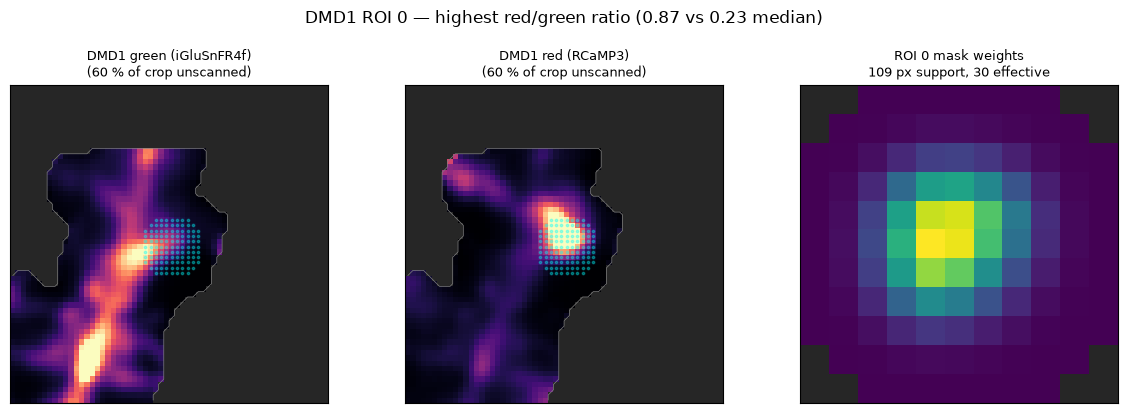

In [25]:
mask = cand_rois.pixel_mask[CAND_ROI]
cy, cx = int(mask['y'].mean()), int(mask['x'].mean())
pad = 30
y0, x0 = max(cy - pad, 0), max(cx - pad, 0)

f, axs = plt.subplots(1, 3, figsize=(12, 4))
for ax, (label, img) in zip(axs, [('green (iGluSnFR4f)', green_full),
                                  ('red (RCaMP3)', red_full)]):
    crop = img[y0:cy + pad, x0:cx + pad]
    lo, hi = np.nanpercentile(crop, [2, 98])
    ax.imshow(crop, cmap='magma', vmin=lo, vmax=hi, interpolation='nearest')
    ax.contour(np.isfinite(crop), levels=[.5], colors='.5', linewidths=.5)
    ax.scatter(mask['x'] - x0, mask['y'] - y0, s=3, color='cyan', alpha=.35)
    ax.set_title(f'{CAND_DMD} {label}\n({100 * np.isnan(crop).mean():.0f} % of crop unscanned)',
                 fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor('.15')

x, y, w = mask['x'].astype(int), mask['y'].astype(int), mask['weight'].astype(float)
grid = np.full((np.ptp(y) + 1, np.ptp(x) + 1), np.nan)
grid[y - y.min(), x - x.min()] = w
axs[2].imshow(grid, cmap='viridis', interpolation='nearest')
axs[2].set_title(f'ROI {CAND_ROI} mask weights\n'
                 f'{int(best.support_px)} px support, '
                 f'{best.effective_px:.0f} effective', fontsize=9)
axs[2].set_xticks([]); axs[2].set_yticks([]); axs[2].set_facecolor('.15')

f.suptitle(f'{CAND_DMD} ROI {CAND_ROI} — highest red/green ratio '
           f'({best.red_over_green:.2f} vs {geom.red_over_green.median():.2f} median)', y=1.02)
f.tight_layout()

Its traces, for comparison with the dendritic ROIs plotted earlier:

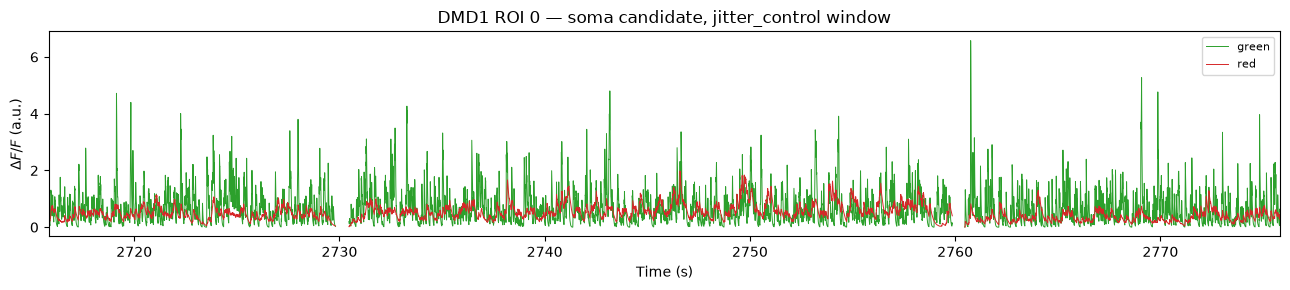

In [26]:
cand_green = stream.slap2_dff(CAND_DMD, channel='green', t_start=t0, t_stop=t1)
cand_red   = stream.slap2_dff(CAND_DMD, channel='red',   t_start=t0, t_stop=t1)
ct = cand_green.columns.to_numpy()

f, ax = plt.subplots(figsize=(13, 3))
ax.plot(ct, cand_green.loc[CAND_ROI].values, lw=.7, color='tab:green', label='green')
ax.plot(ct, cand_red.loc[CAND_ROI].values,   lw=.7, color='tab:red',   label='red')
ax.set_xlim(t0, t1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('$\\Delta F/F$ (a.u.)')
ax.legend(fontsize=8)
ax.set_title(f'{CAND_DMD} ROI {CAND_ROI} — soma candidate, jitter_control window')
f.tight_layout()

## Summary

**On the blocks.** `standard_control` is two presentations of the same standard
block, not one: `Control block 1.1` runs 42-422 s and `Control block 1.2` runs
2036-2417 s, bracketing the oddball block. Grouping every stimulus table on
`(BlockNumber, BlockLabel)` gives nine non-overlapping blocks in presentation
order and avoids the 2375 s phantom block you get from
`standard_control.start_time.min()` to `.stop_time.max()`.

**On the red channel.** It has no ROIs of its own. Both colour channels of a
DMD are read out of the same `PlaneSegmentation`, in the same row order, so
row *i* is the same mask in green and in red — which is why there was no
separate red-channel ROI list to find a soma in. The ROI table has no
type/label column, so the file never says "soma" anywhere.

**On the pixel-count idea.** It cannot work here, for a more basic reason than
it first appears. `n_pixels` counts the mask's *support*, and the support is
shared by neighbouring ROIs: the 458-pixel outlier on DMD2 is one elongated
structure tiled by seven ROIs whose centroids step along it. The weights inside
each mask are a small round kernel of ~30 effective pixels ($1/\sum w^2$), and
that number is essentially constant across all 125 ROIs in both DMDs and
uncorrelated with the support size. Every ROI is the same size, so a soma cannot
stand out by being larger.

**On ROI 0 as a soma.** The best available evidence, and it is suggestive
rather than conclusive. For: it is the one red/green outlier (~0.87 against a
median of ~0.23); in red it is a compact round blob while green shows a process
running past it; and it occupies its own scanned patch, shared with just ROI 1,
whose median red/green ratio (0.56) is by far the highest on DMD1. Against:
DMD1's scanned field breaks into 8 disconnected patches, and ROI 0's is not
continuous with either of the two large dendritic arbors, so no dendrite can be
traced from it to anything else. Confirming it would need the raw SLAP2
reference stack rather than this NWB.